# Audio Spectrogram Analyzer

This notebook demonstrates how to compute and visualize **log-mel spectrograms** from audio files.

## What is a Spectrogram?

A **spectrogram** is a visual representation of how the frequency content of a signal changes over time. Think of it as a 2D plot where:
- **X-axis**: Time
- **Y-axis**: Frequency
- **Color/Intensity**: Energy (amplitude) at that frequency and time

## The Processing Pipeline

To create a mel spectrogram, we follow these steps:

1. **Windowing**: Divide the audio into short overlapping frames (~25ms)
2. **FFT**: Apply Fast Fourier Transform to each frame to get frequency content
3. **Mel Filtering**: Convert linear frequency scale to mel scale (perceptual)
4. **Log Scale**: Convert to decibels (dB) for better visualization

We'll explore each step in detail below.

In [1]:
# Import required libraries
import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display
from scipy.io import wavfile
import os

## Configuration Parameters

### Why These Specific Values?

**Sample Rate (16 kHz)**:
- Nyquist theorem: We can capture frequencies up to 8 kHz (half the sample rate)
- Human speech typically ranges from 80 Hz to 8 kHz, so 16 kHz is sufficient
- Lower sample rate = smaller file size and faster processing

**Window Size (25 ms ≈ 400 samples)**:
- Short enough to capture temporal changes in speech
- Long enough to get good frequency resolution
- Trade-off: Longer windows = better frequency resolution, worse time resolution

**Hop Size (10 ms ≈ 160 samples)**:
- Distance between consecutive windows
- 10 ms hop with 25 ms window = 60% overlap
- Overlap helps smooth the spectrogram and avoid missing transient events

**Mel Bands (64)**:
- Mel scale mimics human perception (we're more sensitive to lower frequencies)
- 64 bands is a good balance between detail and computational efficiency
- Common values: 40, 64, 80, 128

In [2]:
# Configuration parameters
SAMPLE_RATE = 16000  # Hz - samples per second
N_MELS = 64  # Number of mel frequency bands
WINDOW_SIZE_MS = 25  # milliseconds - duration of each analysis window
HOP_SIZE_MS = 10  # milliseconds - time shift between consecutive windows

# Convert milliseconds to samples
# Formula: samples = (milliseconds / 1000) * sample_rate
N_FFT = int(WINDOW_SIZE_MS * SAMPLE_RATE / 1000)  # ~400 samples for 25ms at 16kHz
HOP_LENGTH = int(HOP_SIZE_MS * SAMPLE_RATE / 1000)  # ~160 samples for 10ms at 16kHz

print(f"Sample Rate: {SAMPLE_RATE} Hz")
print(f"Mel Bands: {N_MELS}")
print(f"Window Size: {WINDOW_SIZE_MS} ms ({N_FFT} samples)")
print(f"Hop Size: {HOP_SIZE_MS} ms ({HOP_LENGTH} samples)")
print(f"Frequency Resolution: {SAMPLE_RATE / N_FFT:.2f} Hz per FFT bin")
print(f"Time Resolution: {HOP_SIZE_MS} ms per frame")

Sample Rate: 16000 Hz
Mel Bands: 64
Window Size: 25 ms (400 samples)
Hop Size: 10 ms (160 samples)
Frequency Resolution: 40.00 Hz per FFT bin
Time Resolution: 10 ms per frame


## Step 1: Loading Audio

We load the audio file and ensure it's:
- **Mono** (single channel) - simpler to analyze
- **Resampled** to our target sample rate (16 kHz) if needed

In [3]:
def load_audio(filepath, target_sr=SAMPLE_RATE):
    """
    Load audio file and resample if necessary.
    
    Parameters:
    -----------
    filepath : str
        Path to the WAV file
    target_sr : int
        Target sample rate (default: 16000)
    
    Returns:
    --------
    tuple
        (audio_data, sample_rate)
    """
    print(f"Loading audio from: {filepath}")
    
    # Load audio using librosa (automatically resamples to target_sr)
    audio, sr = librosa.load(filepath, sr=target_sr, mono=True)
    
    duration = len(audio) / sr
    print(f"Audio loaded: {duration:.2f} seconds, {sr} Hz")
    
    return audio, sr

## Step 2: Computing the Mel Spectrogram

### The FFT (Fast Fourier Transform)

The FFT converts a time-domain signal into the frequency domain. For each window:
- **Input**: 400 samples of audio (time domain)
- **Output**: 201 frequency bins (0 Hz to 8 kHz)
- **What it tells us**: How much energy is present at each frequency

### The Mel Scale

The **mel scale** is a perceptual scale of pitches judged by listeners to be equal in distance from one another.

**Why use mel scale?**
- Human hearing is more sensitive to changes in lower frequencies
- Example: We easily distinguish 100 Hz from 200 Hz, but 5000 Hz vs 5100 Hz sounds similar
- Mel scale compresses higher frequencies and expands lower frequencies

**Conversion formula**:
```
mel = 2595 * log10(1 + f/700)
```

### Mel Filterbank

We apply triangular filters spaced evenly on the mel scale:
- Takes 201 FFT bins → produces 64 mel bands
- Lower frequencies get more resolution (more FFT bins per mel band)
- Higher frequencies get less resolution (fewer FFT bins per mel band)

### Power Spectrum

We use `power=2.0`, which means we compute the **power** (magnitude squared):
- Power = |FFT|² 
- Represents energy at each frequency
- More stable than raw magnitude for audio analysis

In [4]:
def compute_log_mel_spectrogram(audio, sr=SAMPLE_RATE, n_mels=N_MELS, 
                                n_fft=N_FFT, hop_length=HOP_LENGTH):
    """
    Compute log-mel spectrogram from audio data.
    
    This function performs the following steps:
    1. Divide audio into overlapping windows (frames)
    2. Apply FFT to each window to get frequency content
    3. Apply mel filterbank to convert to perceptual scale
    4. Convert to log scale (decibels) for better visualization
    
    Parameters:
    -----------
    audio : numpy.ndarray
        Audio time series (1D array of samples)
    sr : int
        Sample rate in Hz (default: 16000)
    n_mels : int
        Number of mel frequency bands (default: 64)
    n_fft : int
        FFT window size in samples (default: 400 for 25ms at 16kHz)
    hop_length : int
        Number of samples between successive frames (default: 160 for 10ms at 16kHz)
    
    Returns:
    --------
    numpy.ndarray
        Log-mel spectrogram with shape (n_mels, n_frames)
    """
    print("Computing mel spectrogram...")
    
    # Step 1-3: Windowing, FFT, and Mel filtering
    # librosa does all of this in one function
    mel_spec = librosa.feature.melspectrogram(
        y=audio,           # Input audio signal
        sr=sr,             # Sample rate
        n_mels=n_mels,     # Number of mel bands to generate
        n_fft=n_fft,       # Length of FFT window
        hop_length=hop_length,  # Number of samples between frames
        power=2.0          # Use power spectrogram (magnitude squared)
    )
    
    # Step 4: Convert to log scale (decibels)
    # Why log scale?
    # - Human perception of loudness is logarithmic
    # - Makes quiet sounds more visible in the visualization
    # - Formula: dB = 10 * log10(power / reference)
    log_mel_spec = librosa.power_to_db(mel_spec, ref=np.max)
    
    print(f"Spectrogram shape: {log_mel_spec.shape} (mel_bands x time_frames)")
    print(f"Value range: {log_mel_spec.min():.1f} dB to {log_mel_spec.max():.1f} dB")
    
    return log_mel_spec

## Understanding the Output

The resulting spectrogram is a 2D array:
- **Rows (64)**: Mel frequency bands (low to high frequency)
- **Columns (varies)**: Time frames
- **Values**: Energy in decibels (dB), typically ranging from -80 dB to 0 dB

**Example**: For a 3-second audio clip:
- Number of frames = (3 seconds × 1000 ms/s) / 10 ms = 300 frames
- Output shape: (64, 300)

## Step 3: Visualization

### Reading the Spectrogram

When you look at the spectrogram:
- **Bright/Yellow areas**: High energy (loud) at that frequency and time
- **Dark/Purple areas**: Low energy (quiet) at that frequency and time
- **Horizontal lines**: Sustained tones (like vowels in speech)
- **Vertical lines**: Transient sounds (like consonants or percussive sounds)
- **Harmonic patterns**: Multiple horizontal lines stacked = fundamental frequency + harmonics

### Decibel Scale

The colorbar shows values in **decibels (dB)**:
- 0 dB = maximum energy in the signal (reference point)
- -20 dB = 1/100th of the maximum energy
- -40 dB = 1/10,000th of the maximum energy
- Values below -80 dB are typically considered silence/noise floor

In [5]:
def plot_log_mel_spectrogram(log_mel_spec, sr=SAMPLE_RATE, hop_length=HOP_LENGTH, 
                             title="Log-Mel Spectrogram", save_path=None):
    """
    Display log-mel spectrogram using matplotlib.
    
    Parameters:
    -----------
    log_mel_spec : numpy.ndarray
        Log-mel spectrogram to display (shape: n_mels x n_frames)
    sr : int
        Sample rate in Hz (default: 16000)
    hop_length : int
        Hop length in samples used in spectrogram computation (default: 160)
    title : str
        Plot title
    save_path : str, optional
        If provided, save the plot to this file path
    """
    plt.figure(figsize=(12, 6))
    
    # Display spectrogram with proper axes
    img = librosa.display.specshow(
        log_mel_spec,      # The spectrogram data
        sr=sr,             # Sample rate (for time axis calculation)
        hop_length=hop_length,  # Hop length (for time axis calculation)
        x_axis='time',     # X-axis shows time in seconds
        y_axis='mel',      # Y-axis shows mel frequency scale
        cmap='viridis'     # Color map: purple (low) to yellow (high)
    )
    
    # Add colorbar to show dB scale
    plt.colorbar(img, format='%+2.0f dB', label='Energy (dB)')
    plt.title(title, fontsize=14)
    plt.xlabel('Time (s)', fontsize=12)
    plt.ylabel('Mel Frequency', fontsize=12)
    plt.tight_layout()
    
    # Save the plot if save_path is provided
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Spectrogram saved to: {save_path}")
    
    plt.show()

## Saving Spectrograms

We can save the spectrogram plots as image files for:
- Documentation and reports
- Comparison across different audio files
- Machine learning datasets (visual features)
- Presentations and publications

The plots are saved as high-resolution PNG files (300 DPI) with timestamps in the filename.

In [6]:
def save_spectrogram_plot(log_mel_spec, audio_filename, sr=SAMPLE_RATE, 
                          hop_length=HOP_LENGTH, output_dir='results'):
    """
    Save spectrogram plot to a file with timestamp.
    
    Parameters:
    -----------
    log_mel_spec : numpy.ndarray
        Log-mel spectrogram to save
    audio_filename : str
        Original audio filename (used to generate output filename)
    sr : int
        Sample rate (default: 16000)
    hop_length : int
        Hop length (default: 160)
    output_dir : str
        Directory to save the plot (default: 'results')
    
    Returns:
    --------
    str
        Path to the saved file
    """
    # Create output directory if it doesn't exist
    os.makedirs(output_dir, exist_ok=True)
    
    # Generate output filename based on input audio filename
    from datetime import datetime
    base_name = os.path.splitext(os.path.basename(audio_filename))[0]
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    output_filename = f"spectrogram_{base_name}_{timestamp}.png"
    output_path = os.path.join(output_dir, output_filename)
    
    # Create and save the plot
    title = f"Log-Mel Spectrogram - {os.path.basename(audio_filename)}"
    plot_log_mel_spectrogram(log_mel_spec, sr, hop_length, title, save_path=output_path)
    
    return output_path

In [12]:
# Specify the path to your WAV file
# Example: Use the most recent recording from the recordings directory
recordings_dir = 'recordings'

# Get the most recent WAV file
if os.path.exists(recordings_dir):
    wav_files = [f for f in os.listdir(recordings_dir) if f.endswith('.wav')]
    if wav_files:
        wav_files.sort(reverse=True)  # Sort by name (timestamp)
        audio_file = os.path.join(recordings_dir, wav_files[0])
        print(f"Using most recent recording: {audio_file}")
    else:
        audio_file = 'path/to/your/audio.wav'  # Replace with your file path
        print(f"No recordings found. Please specify a file path.")
else:
    audio_file = 'path/to/your/audio.wav'  # Replace with your file path
    print(f"Recordings directory not found. Please specify a file path.")

Using most recent recording: recordings/recording_20260111_195622.wav


In [13]:
# Load the audio file
audio, sr = load_audio(audio_file)

Loading audio from: recordings/recording_20260111_195622.wav
Audio loaded: 6.00 seconds, 16000 Hz


In [14]:
# Compute log-mel spectrogram
log_mel_spec = compute_log_mel_spectrogram(audio, sr)

Computing mel spectrogram...
Spectrogram shape: (64, 601) (mel_bands x time_frames)
Value range: -80.0 dB to 0.0 dB


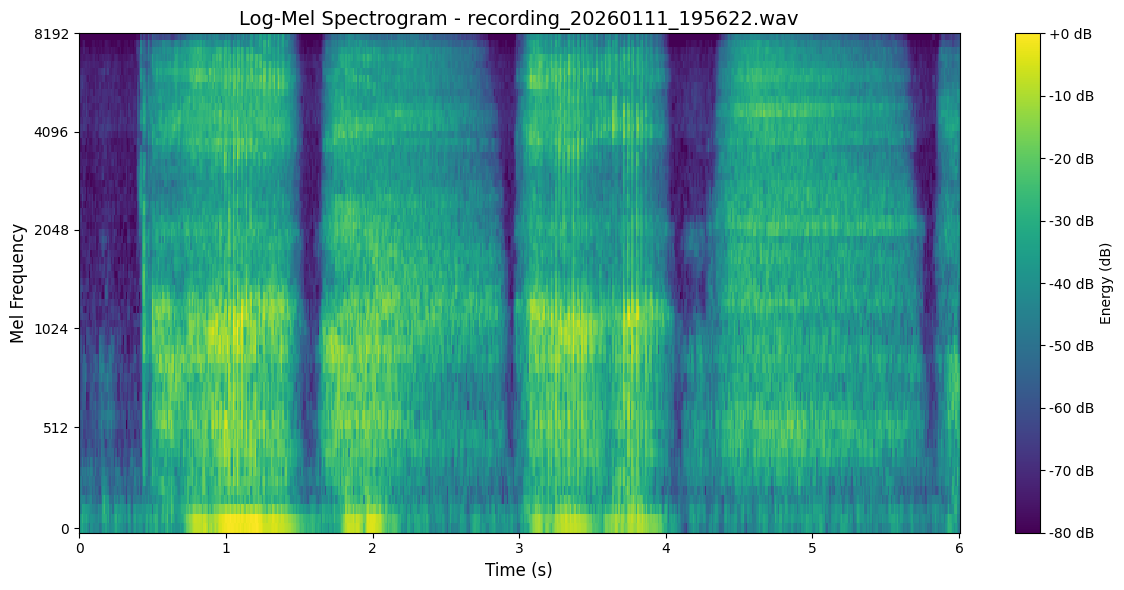

In [15]:
# Display the spectrogram
plot_log_mel_spectrogram(log_mel_spec, sr, title=f"Log-Mel Spectrogram - {os.path.basename(audio_file)}")

Spectrogram saved to: results/spectrogram_recording_20260111_195622_20260111_195631.png


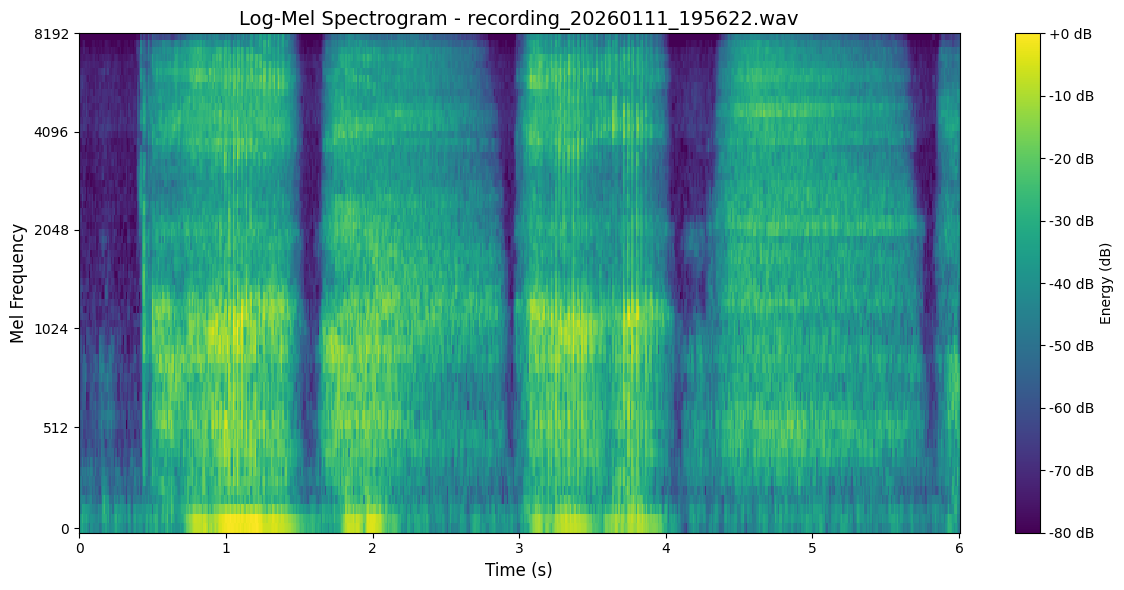

In [16]:
# Save the spectrogram plot to the results directory
saved_path = save_spectrogram_plot(log_mel_spec, audio_file, sr)

In [ ]:
# Optional: Analyze a different file
# Uncomment and modify the path below
# custom_audio_file = 'path/to/another/audio.wav'
# audio, sr = load_audio(custom_audio_file)
# log_mel_spec = compute_log_mel_spectrogram(audio, sr)
# saved_path = save_spectrogram_plot(log_mel_spec, custom_audio_file, sr)

---

## Summary: The Complete Pipeline

### 1. Time Domain → Frequency Domain (FFT)
```
Audio samples → Windowing → FFT → Frequency bins
[400 samples] → [Hamming window] → [FFT] → [201 frequency bins]
```

### 2. Linear Frequency → Mel Frequency
```
Linear scale (0-8000 Hz) → Mel filterbank → Mel scale
[201 bins] → [Triangular filters] → [64 mel bands]
```

### 3. Power → Decibels
```
Power spectrum → Log scale → dB
[Linear scale] → [10 * log10(power)] → [-80 to 0 dB]
```

### Key Takeaways

1. **FFT** converts time-domain audio into frequency components
2. **Windowing** allows us to see how frequencies change over time
3. **Mel scale** matches human perception of pitch
4. **Log scale (dB)** matches human perception of loudness
5. **Overlap** between windows ensures we don't miss transient events

### Trade-offs to Remember

- **Longer windows** → Better frequency resolution, worse time resolution
- **Shorter windows** → Better time resolution, worse frequency resolution
- **More mel bands** → More detail, larger data size
- **Fewer mel bands** → Less detail, smaller data size

This is called the **time-frequency trade-off** and is fundamental to signal processing!